In [1]:
import numpy as np
import pandas as pd
import random
import math
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import sys

sys.path.insert(0, "../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [3]:
f = open(f"data/{NUTS0}_WNV_{NUTS2}_cases_dates.txt", "r")
print(f.read())

months: 6, 7, 8, 9, 10, 
years: 2010, 2011, 2012, 2013, 2018, 2019, 2020, 2021, 


In [4]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'

In [5]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,mosq_pred,mosq_previous,case
0,24.12740,40.28807,2010-01-01,κεντρικης μακεδονιας,αθως,28,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,NaN,NaN,NaN,46.96020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.642500,15.530000,9.755000,10.633286,6.832500,8.883182,3.811746,13.083628,6.037902,16.634859,8.565833,34.075000,97.500000,0.575000,741.395353,5480.994362,0,229.615930,142.067691,199.028237,134451.168165,1.385666,1,0,0
1,22.41314,40.63121,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,7,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.40306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.705000,12.360000,7.050000,6.907708,4.406161,10.730556,1.957517,19.149590,4.396618,28.020071,9.308866,14.800000,40.250000,0.000000,19302.853155,218.518170,4,165.845298,4.439405,180.217997,0.000000,252.542758,1,0,0
2,22.07467,40.99173,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,13,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.55763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.388182,9.579091,5.197273,3.313442,2.001560,3.998298,0.826676,11.100321,2.044771,19.138418,5.884069,20.218182,39.590909,0.045455,23100.611480,687.499343,0,127.752566,125.810202,179.704207,0.000000,1.162002,1,0,0
3,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,17,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,15.000000,39.900000,0.000000,783.725557,1072.158690,3,157.852939,3.721570,180.299131,0.000000,56.126569,3,0,0
4,23.97067,40.91960,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,35,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.42369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.135000,12.090000,8.180000,8.143000,3.953714,10.209315,2.185636,15.249258,3.555705,20.722821,8.455035,20.225000,29.825000,0.000000,16692.000632,304.097354,4,255.084988,347.388991,187.472171,0.000000,20.820754,1,0,0


In [6]:
dataset = dataset.query('month >= 6 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [7]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,301,250,551,11.07%
1,2011,366,31,397,7.98%
2,2012,371,20,391,7.86%
3,2013,373,21,394,7.92%
4,2014,390,0,390,7.84%
5,2015,390,0,390,7.84%
6,2016,390,0,390,7.84%
7,2017,390,0,390,7.84%
8,2018,321,117,438,8.80%
9,2019,354,53,407,8.18%


In [8]:
feature_list = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns.tolist()

In [9]:
#Use all data for training

ft_importance = pd.DataFrame()

for feature in feature_list:
    print(f"Training without feature: '{feature}'")
    X_train = dataset.select_dtypes(exclude=['object']).drop(columns = ['case', feature])
    y_train = dataset['case']

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)

    imputer = KNNImputer()
    X_train = imputer.fit_transform(X_train)

    try:
        class_0_counts = y_train.value_counts()[0]
    except KeyError:
        class_0_counts = 0
    try:
        class_1_counts = y_train.value_counts()[1]
    except KeyError:
        class_1_counts = 0
        
    if (near_u != 0):
        nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
        X_train, y_train = nm.fit_resample(X_train, y_train)
    
    if (smote != 0):
        class_0_counts = y_train.value_counts()[0]
        sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
        X_train, y_train = sm.fit_resample(X_train, y_train)

    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_train)

    loss = log_loss(y_train, probabilities)

    ft_importance = ft_importance.append({'Feature': feature,
                                          'Loss': loss}, ignore_index = True)

Training without feature: 'x'
Training without feature: 'y'
Training without feature: 'lau1_id'
Training without feature: 'day'
Training without feature: 'month'
Training without feature: 'week'
Training without feature: 'year'
Training without feature: 'day_sin'
Training without feature: 'day_cos'
Training without feature: 'month_sin'
Training without feature: 'month_cos'
Training without feature: 'week_sin'
Training without feature: 'week_cos'
Training without feature: 'area'
Training without feature: 'population'
Training without feature: 'population_density'
Training without feature: 'eq_distance'
Training without feature: 'ndvi'
Training without feature: 'ndmi'
Training without feature: 'ndwi'
Training without feature: 'ndbi'
Training without feature: 'ndvi_mean'
Training without feature: 'ndmi_mean'
Training without feature: 'ndwi_mean'
Training without feature: 'ndbi_mean'
Training without feature: 'ndvi_std'
Training without feature: 'ndmi_std'
Training without feature: 'ndwi_s

In [10]:
# Split in train and test

# ft_importance = pd.DataFrame()

# for feature in feature_list:
#     print(f"Training without feature: '{feature}'")
#     X = dataset.select_dtypes(exclude=['object']).drop(columns = ['case', feature])
#     y = dataset['case']

#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify = y, random_state = 0)

#     scaler = MinMaxScaler()
#     X_train = scaler.fit_transform(X_train)
#     X_test = scaler.transform(X_test)

#     imputer = KNNImputer()
#     X_train = imputer.fit_transform(X_train)
#     X_test = imputer.transform(X_test)

#     try:
#         class_0_counts = y_train.value_counts()[0]
#     except KeyError:
#         class_0_counts = 0
#     try:
#         class_1_counts = y_train.value_counts()[1]
#     except KeyError:
#         class_1_counts = 0
        
#     if (near_u != 0):
#         nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
#         X_train, y_train = nm.fit_resample(X_train, y_train)
    
#     if (smote != 0):
#         class_0_counts = y_train.value_counts()[0]
#         sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
#         X_train, y_train = sm.fit_resample(X_train, y_train)

#     w0,w1 = calculate_weights(y_train)

#     model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
#     model.fit(X_train, y_train)

#     probabilities_test = model.predict_proba(X_test)

#     loss = log_loss(y_test, probabilities_test)

#     ft_importance = ft_importance.append({'Feature': feature,
#                                           'Loss': loss}, ignore_index = True)

In [11]:
ft_importance.sort_values(by=['Loss'], ascending=True, inplace=True)

In [12]:
losses = ft_importance['Loss']
shp = losses.shape[0]
losses = losses.to_numpy().reshape(1,shp)

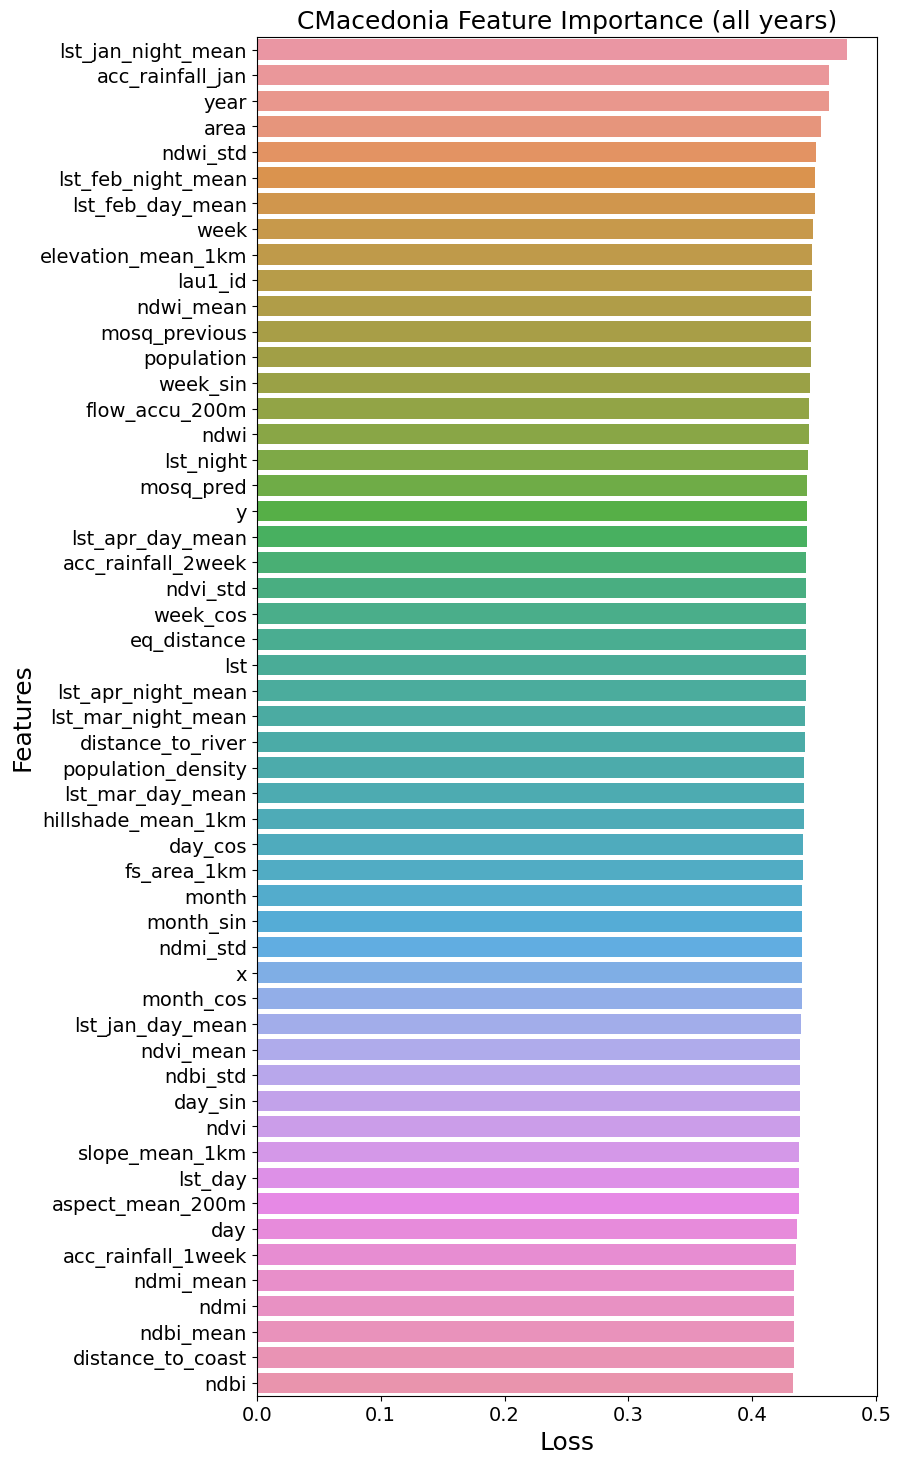

In [13]:
plot_feature_importance(losses, ft_importance['Feature'], x_label = 'Loss', title = f'{NUTS2} Feature Importance (all years)', title_size=18)

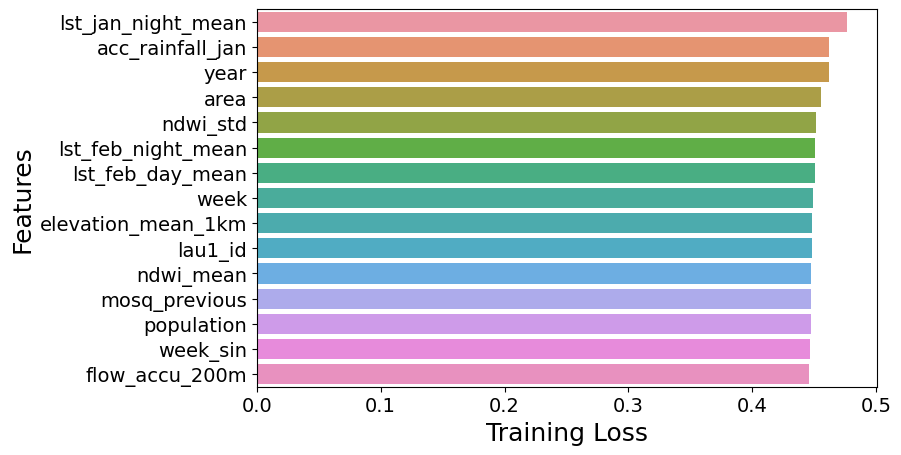

In [15]:
plot_feature_importance(losses, ft_importance['Feature'], x_label = 'Training Loss', top = 15, figure_size= (8,5))